# TPOSE validation vs GLORYS12 reanalysis

The TPOSE6 (1/6°) and TPOSE24 (1/24°) runs are compared to the GLORYS12
reanalysis (1/12°) over the Oct 1 – Dec 30 2012 overlap window on the
common (nested TPOSE24) domain.  Models are daily-sampled and regridded
onto the GLORYS grid; all spatial statistics use cos(latitude) weighting.

- **SST** — time-mean maps, bias maps, domain-mean RMSE/bias time series, equatorial-band structure.
- **SSH** — domain mean removed from every product; time-mean pattern, zonal tilt, anomaly variability, differences.
- **Surface currents** — speed maps + mean vectors, equatorial zonal current, meridional structure, speed bias.
- **Temperature** — domain-mean profile, equatorial depth–longitude transect + difference, temporal variability, 140°W meridional section.
- **Salinity** — same set as temperature.

Runs are listed in `MODELS`; every figure scales with the number of runs.

In [1]:
# ════════════════════════════════════════════════════════════════════
#  RUNS TO VALIDATE  —  (label, config)
#  daily_step samples the diagnostic output down to ~daily cadence for the
#  3-D reads (TPOSE24 output is 3-hourly -> every 8th; TPOSE6 is daily -> 1).
# ════════════════════════════════════════════════════════════════════
MODELS = [
    ('TPOSE6',  dict(run_dir='/data/SO3/edavenport/tpose6/diags/sep2012/run_iter14',
                     grid_dir='/data/SO6/TPOSE_diags/tpose6/grid_6',
                     ref_date='2012-09-01', delta_t=1200, daily_step=1)),
    ('TPOSE24', dict(run_dir='/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3',
                     grid_dir=None, ref_date='2012-10-01', delta_t=300, daily_step=8)),
]

GLORYS_MONTHS = ['2012_10', '2012_11', '2012_12']
OUTDIR      = 'GLORYS_comparison'
T0, T1      = '2012-10-01', '2012-12-30'   # common daily window
DEPTH_MAX   = 400.0                         # m, for profiles / transects
EQ_HALF     = 0.5                           # deg, equatorial transect band
BAND_HALF   = 2.0                           # deg, equatorial surface band
SECTION_LON = 220.0                         # 140°W meridional section

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo

import obs_validation_utils as u
import glorys_validation_utils as g

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
os.makedirs(OUTDIR, exist_ok=True)

LABELS  = [m[0] for m in MODELS]
COLORS  = {lbl: u.model_color(i) for i, lbl in enumerate(LABELS)}
print(f'{len(MODELS)} run(s):', LABELS, '| figures ->', OUTDIR)

2 run(s): ['TPOSE6', 'TPOSE24'] | figures -> GLORYS_comparison


In [3]:
# ── Load GLORYS and open every model (lazy) ─────────────────────────
glor = g.load_glorys(GLORYS_MONTHS).sel(time=slice(T0, T1))
print('GLORYS', str(glor.time.values[0])[:10], '->', str(glor.time.values[-1])[:10],
      '| depth 0 –', round(float(glor.depth.max()), 1), 'm')

state_ds, surf_ds, domains = {}, {}, []
for label, cfg in MODELS:
    state_ds[label] = g.load_model(cfg['run_dir'], cfg['grid_dir'], prefix=['diag_state'],
                                   ref_date=cfg['ref_date'], delta_t=cfg['delta_t'])
    surf_ds[label]  = g.load_model(cfg['run_dir'], cfg['grid_dir'], prefix=['diag_surf'],
                                   ref_date=cfg['ref_date'], delta_t=cfg['delta_t'])
    domains.append(u.model_domain(state_ds[label]))

DOM = g.domain_intersection(domains)
print('comparison domain (lon0, lon1, lat0, lat1) =', tuple(round(d, 2) for d in DOM))

GLORYS 2012-10-01 -> 2012-12-30 | depth 0 – 453.9 m


comparison domain (lon0, lon1, lat0, lat1) = (209.35, 230.65, -5.48, 10.48)


In [4]:
# ── Helper plot primitives ──────────────────────────────────────────
def add_map(ax, lon, lat, field, cmap, vmin, vmax):
    im = ax.pcolormesh(lon, lat, field, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Lon (°E)')
    return im

def add_transect(ax, x, depth, field, cmap, vmin, vmax, xlabel):
    im = ax.pcolormesh(x, depth, field, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.set_ylim(depth.max(), 0)
    ax.set_xlabel(xlabel)
    return im

PRODUCTS = ['GLORYS'] + LABELS   # panel order

In [5]:
# ── GLORYS surface fields on the comparison domain ──────────────────
sst_o = u.subset_domain(glor.thetao.isel(depth=0), *DOM).compute()
uo_o  = u.subset_domain(glor.uo.isel(depth=0),     *DOM).compute()
vo_o  = u.subset_domain(glor.vo.isel(depth=0),     *DOM).compute()
zos_o = u.subset_domain(glor.zos,                  *DOM).compute()

LON = sst_o.longitude.values
LAT = sst_o.latitude.values
print('GLORYS grid on domain:', sst_o.shape, '(time, lat, lon)')

GLORYS grid on domain: (91, 186, 255) (time, lat, lon)


In [6]:
# ── Regrid each model surface field onto the GLORYS grid, align days ─
def prep(model_da, obs_da):
    m, o = u.align_daily(model_da, obs_da)
    return m.values, o.values, pd.to_datetime(m.time.values)

surf = {}
for label, _ in MODELS:
    sds, fds = state_ds[label], surf_ds[label]
    sst = u.daily_mean(sds.THETA.isel(Z=0).where(sds.THETA.isel(Z=0) != 0))
    uu  = u.daily_mean(sds.UVEL.isel(Z=0).where(sds.UVEL.isel(Z=0) != 0))
    vv  = u.daily_mean(sds.VVEL.isel(Z=0).where(sds.VVEL.isel(Z=0) != 0))
    eta = u.daily_mean(fds.ETAN.where(fds.ETAN != 0))

    msst, osst, tt = prep(u.regrid_model_to_obs(sst, LON, LAT, x='XC', y='YC'), sst_o)
    mu,   ou,  _   = prep(u.regrid_model_to_obs(uu,  LON, LAT, x='XG', y='YC'), uo_o)
    mv,   ov,  _   = prep(u.regrid_model_to_obs(vv,  LON, LAT, x='XC', y='YG'), vo_o)
    meta, oeta, _  = prep(u.regrid_model_to_obs(eta, LON, LAT, x='XC', y='YC'), zos_o)

    surf[label] = dict(sst=msst, u=mu, v=mv, eta=meta,
                       osst=osst, ou=ou, ov=ov, oeta=oeta, time=tt)
    print(f'[{label}] surface aligned days: {len(tt)}')

# GLORYS reference (identical days across runs)
ref = surf[LABELS[0]]
OBS = dict(sst=ref['osst'], u=ref['ou'], v=ref['ov'], eta=ref['oeta'])

[TPOSE6] surface aligned days: 91


[TPOSE24] surface aligned days: 91


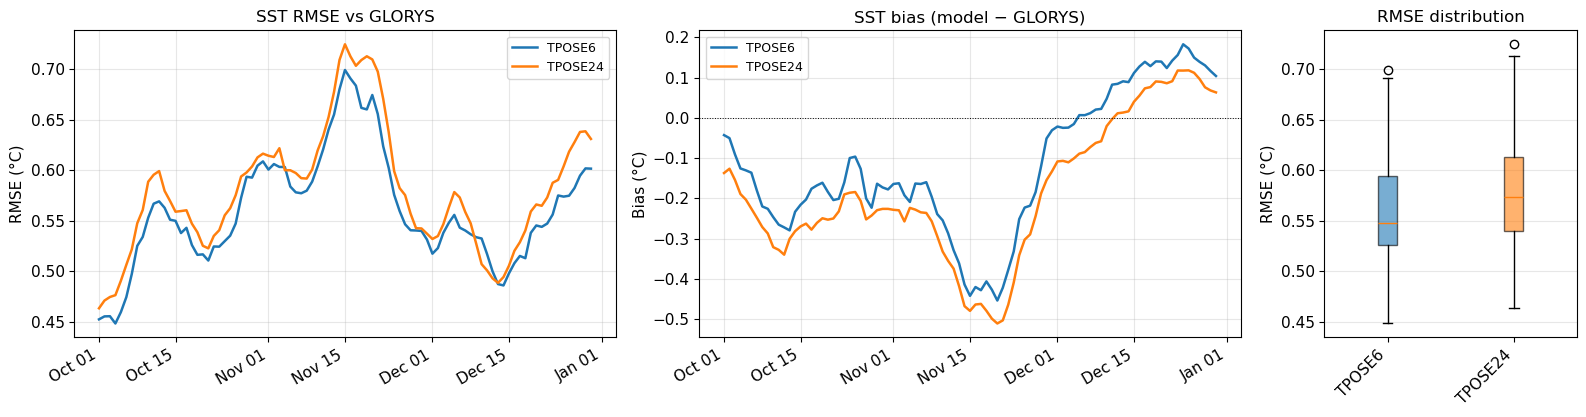

In [7]:
# ── SST: domain-mean RMSE & bias time series + box summary ──────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3),
                         gridspec_kw={'width_ratios': [3, 3, 1.4]})
box = []
for label in LABELS:
    m, o, tt = surf[label]['sst'], surf[label]['osst'], surf[label]['time']
    rmse = u.weighted_spatial_rmse(m, o, LAT)
    bias = u.weighted_spatial_bias(m, o, LAT)
    axes[0].plot(tt, rmse, color=COLORS[label], lw=1.8, label=label)
    axes[1].plot(tt, bias, color=COLORS[label], lw=1.8, label=label)
    box.append(rmse)
axes[0].set_title('SST RMSE vs GLORYS'); axes[0].set_ylabel('RMSE (°C)')
axes[1].axhline(0, color='k', lw=0.7, ls=':')
axes[1].set_title('SST bias (model − GLORYS)'); axes[1].set_ylabel('Bias (°C)')
for ax in axes[:2]:
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
bp = axes[2].boxplot(box, labels=LABELS, patch_artist=True)
for k, patch in enumerate(bp['boxes']):
    patch.set_facecolor(COLORS[LABELS[k]]); patch.set_alpha(0.6)
axes[2].set_title('RMSE distribution'); axes[2].set_ylabel('RMSE (°C)')
axes[2].grid(alpha=0.3, axis='y')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/sst_1d_rmse_bias_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

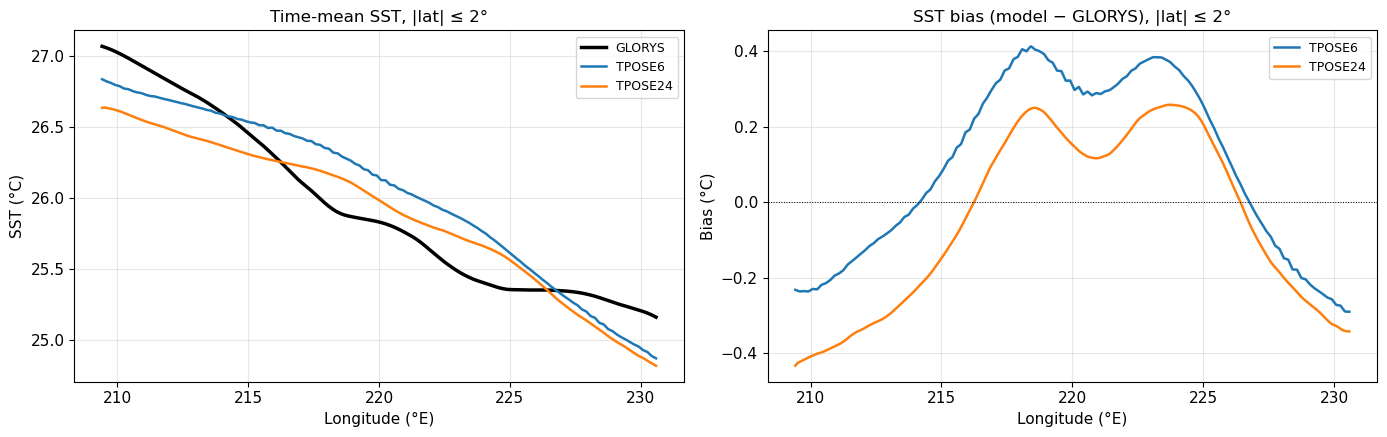

In [8]:
# ── SST: time-mean & bias in the equatorial band vs longitude ───────
band = np.abs(LAT) <= BAND_HALF
w = np.cos(np.deg2rad(LAT[band]))[:, None]
def bm(a2d):
    a = a2d[band, :]
    return np.nansum(a * w, axis=0) / np.nansum(w * np.isfinite(a), axis=0)

obs_mean = np.nanmean(OBS['sst'], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(LON, bm(obs_mean), color='k', lw=2.5, label='GLORYS')
for label in LABELS:
    mmean = np.nanmean(surf[label]['sst'], axis=0)
    bmap  = np.nanmean(surf[label]['sst'] - surf[label]['osst'], axis=0)
    axes[0].plot(LON, bm(mmean), color=COLORS[label], lw=1.8, label=label)
    axes[1].plot(LON, bm(bmap),  color=COLORS[label], lw=1.8, label=label)
axes[0].set_title(f'Time-mean SST, |lat| ≤ {BAND_HALF:g}°'); axes[0].set_ylabel('SST (°C)')
axes[1].axhline(0, color='k', lw=0.7, ls=':')
axes[1].set_title(f'SST bias (model − GLORYS), |lat| ≤ {BAND_HALF:g}°'); axes[1].set_ylabel('Bias (°C)')
for ax in axes:
    ax.set_xlabel('Longitude (°E)'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/sst_1d_zonal_structure.png', dpi=150, bbox_inches='tight')
plt.show()

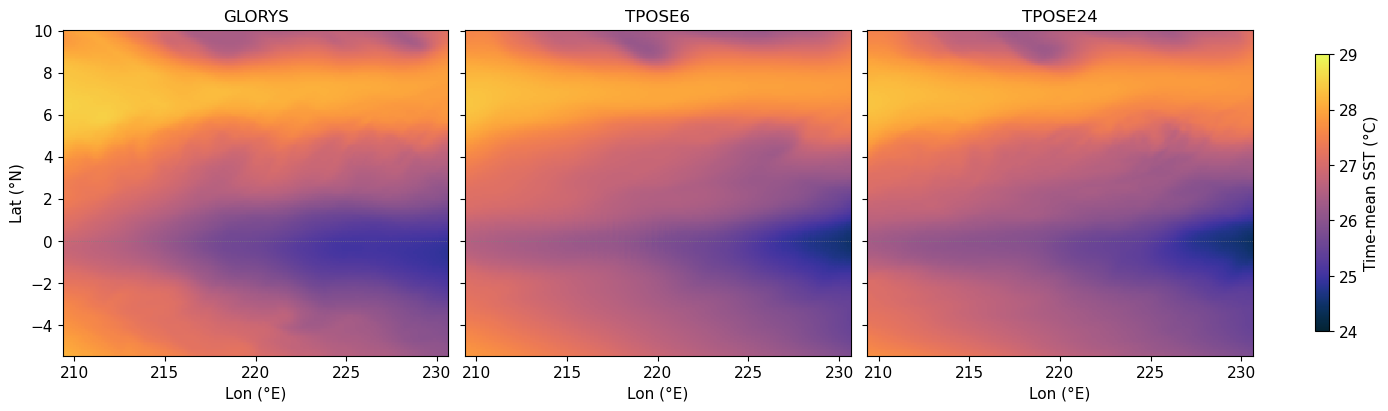

In [9]:
# ── SST: time-mean maps (GLORYS + each run) ─────────────────────────
maps = {'GLORYS': np.nanmean(OBS['sst'], axis=0)}
for label in LABELS:
    maps[label] = np.nanmean(surf[label]['sst'], axis=0)
vmin = np.floor(np.nanmin(maps['GLORYS'])); vmax = np.ceil(np.nanmax(maps['GLORYS']))
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    im = add_map(ax, LON, LAT, maps[p], cmo.thermal, vmin, vmax); ax.set_title(p)
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Time-mean SST (°C)', shrink=0.85)
fig.savefig(f'{OUTDIR}/sst_2d_mean_maps.png', dpi=150, bbox_inches='tight')
plt.show()

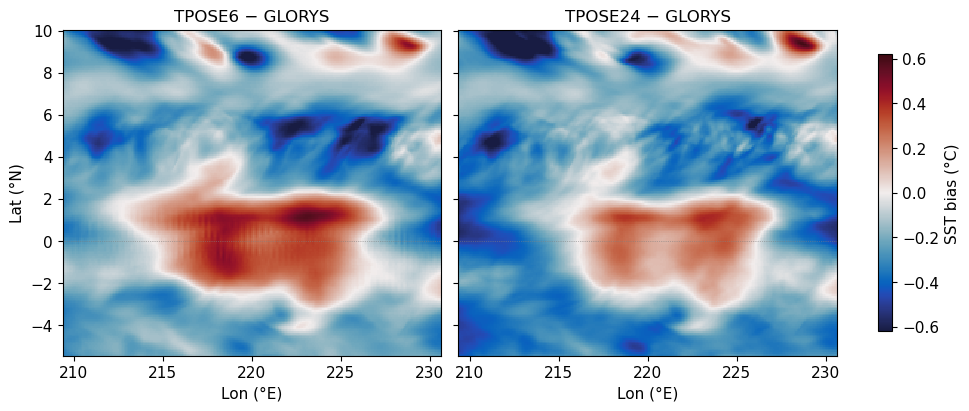

In [10]:
# ── SST: bias maps (model − GLORYS) ─────────────────────────────────
bias_maps = {label: np.nanmean(surf[label]['sst'] - surf[label]['osst'], axis=0)
             for label in LABELS}
bmax = np.nanmax([np.nanpercentile(np.abs(b), 99) for b in bias_maps.values()])
n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True, squeeze=False)
axes = axes[0]
for ax, label in zip(axes, LABELS):
    im = add_map(ax, LON, LAT, bias_maps[label], cmo.balance, -bmax, bmax)
    ax.set_title(f'{label} − GLORYS')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='SST bias (°C)', shrink=0.85)
fig.savefig(f'{OUTDIR}/sst_2d_bias_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── SSH: remove the domain mean from every product (per timestep) ───
ssh = {'GLORYS': g.remove_domain_mean(OBS['eta'], LAT)}
for label in LABELS:
    ssh[label] = g.remove_domain_mean(surf[label]['eta'], LAT)

# time-mean pattern (domain-mean-removed) and per-pixel temporal anomaly
tmean = {p: np.nanmean(ssh[p], axis=0) for p in PRODUCTS}
anom  = {p: ssh[p] - np.nanmean(ssh[p], axis=0, keepdims=True) for p in PRODUCTS}

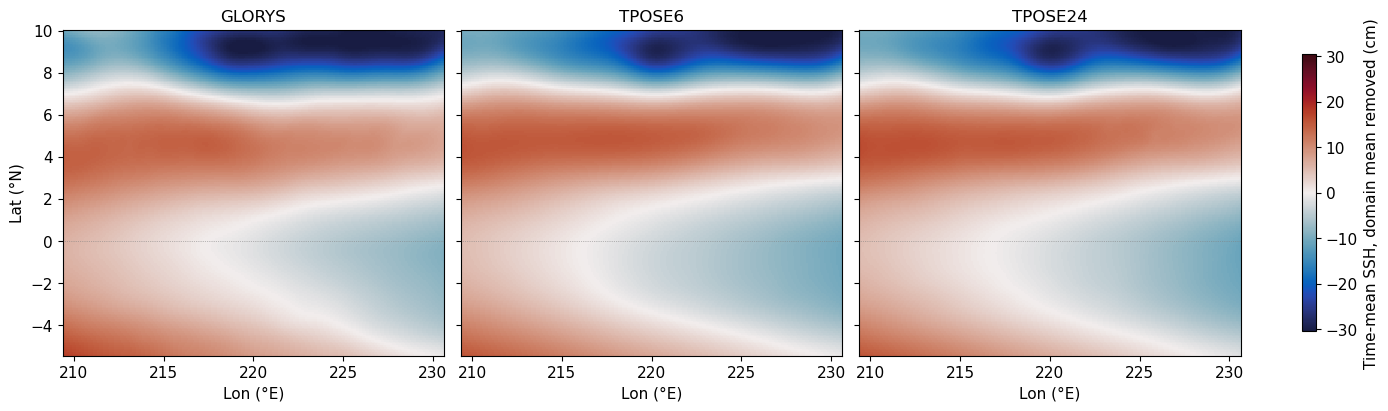

In [12]:
# ── SSH: time-mean maps (domain mean removed) ───────────────────────
smax = np.nanmax([np.nanpercentile(np.abs(tmean[p]), 99) for p in PRODUCTS])
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    im = add_map(ax, LON, LAT, tmean[p] * 100, cmo.balance, -smax * 100, smax * 100)
    ax.set_title(p)
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Time-mean SSH, domain mean removed (cm)', shrink=0.85)
fig.savefig(f'{OUTDIR}/ssh_2d_mean_maps.png', dpi=150, bbox_inches='tight')
plt.show()

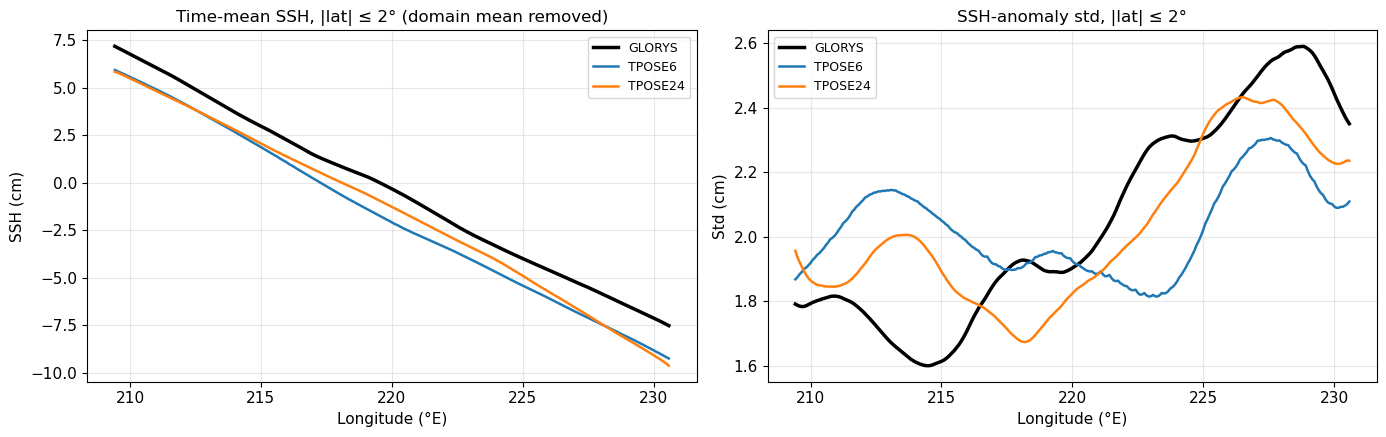

In [13]:
# ── SSH: equatorial zonal tilt + anomaly std vs longitude ───────────
band = np.abs(LAT) <= BAND_HALF
w = np.cos(np.deg2rad(LAT[band]))[:, None]
def bm(a2d):
    a = a2d[band, :]
    return np.nansum(a * w, axis=0) / np.nansum(w * np.isfinite(a), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for p in PRODUCTS:
    c = 'k' if p == 'GLORYS' else COLORS[p]
    lw = 2.5 if p == 'GLORYS' else 1.8
    axes[0].plot(LON, bm(tmean[p]) * 100, color=c, lw=lw, label=p)
    axes[1].plot(LON, bm(np.nanstd(anom[p], axis=0)) * 100, color=c, lw=lw, label=p)
axes[0].set_title(f'Time-mean SSH, |lat| ≤ {BAND_HALF:g}° (domain mean removed)')
axes[0].set_ylabel('SSH (cm)')
axes[1].set_title(f'SSH-anomaly std, |lat| ≤ {BAND_HALF:g}°')
axes[1].set_ylabel('Std (cm)')
for ax in axes:
    ax.set_xlabel('Longitude (°E)'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/ssh_1d_tilt_variability.png', dpi=150, bbox_inches='tight')
plt.show()

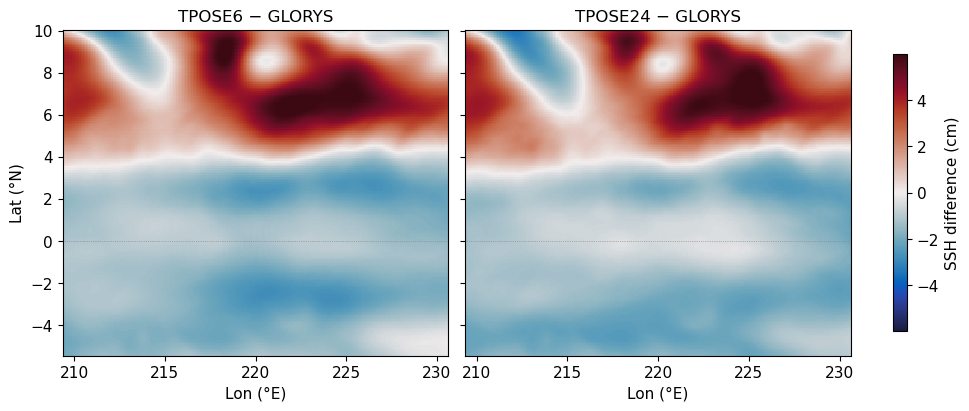

In [14]:
# ── SSH: time-mean difference maps (model − GLORYS) ─────────────────
diff = {label: tmean[label] - tmean['GLORYS'] for label in LABELS}
dmax = np.nanmax([np.nanpercentile(np.abs(d), 99) for d in diff.values()])
n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True, squeeze=False)
axes = axes[0]
for ax, label in zip(axes, LABELS):
    im = add_map(ax, LON, LAT, diff[label] * 100, cmo.balance, -dmax * 100, dmax * 100)
    ax.set_title(f'{label} − GLORYS')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='SSH difference (cm)', shrink=0.85)
fig.savefig(f'{OUTDIR}/ssh_2d_diff_maps.png', dpi=150, bbox_inches='tight')
plt.show()

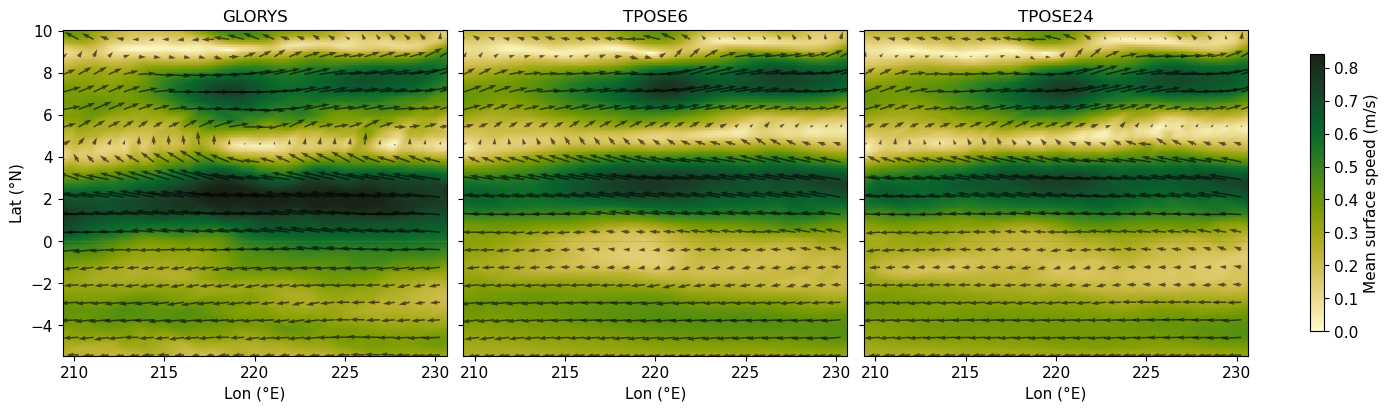

In [15]:
# ── Surface currents: mean speed maps + mean vectors ────────────────
spd = {'GLORYS': np.sqrt(np.nanmean(OBS['u'], 0)**2 + np.nanmean(OBS['v'], 0)**2)}
umean = {'GLORYS': np.nanmean(OBS['u'], 0)}; vmean = {'GLORYS': np.nanmean(OBS['v'], 0)}
for label in LABELS:
    um = np.nanmean(surf[label]['u'], 0); vm = np.nanmean(surf[label]['v'], 0)
    umean[label] = um; vmean[label] = vm
    spd[label] = np.sqrt(um**2 + vm**2)

vmax = np.nanpercentile(spd['GLORYS'], 99)
q = max(1, len(LON) // 25)
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    im = add_map(ax, LON, LAT, spd[p], cmo.speed, 0, vmax)
    ax.quiver(LON[::q], LAT[::q], umean[p][::q, ::q], vmean[p][::q, ::q],
              scale=8, width=0.004, color='k', alpha=0.6)
    ax.set_title(p)
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Mean surface speed (m/s)', shrink=0.85)
fig.savefig(f'{OUTDIR}/currents_2d_speed_vectors.png', dpi=150, bbox_inches='tight')
plt.show()

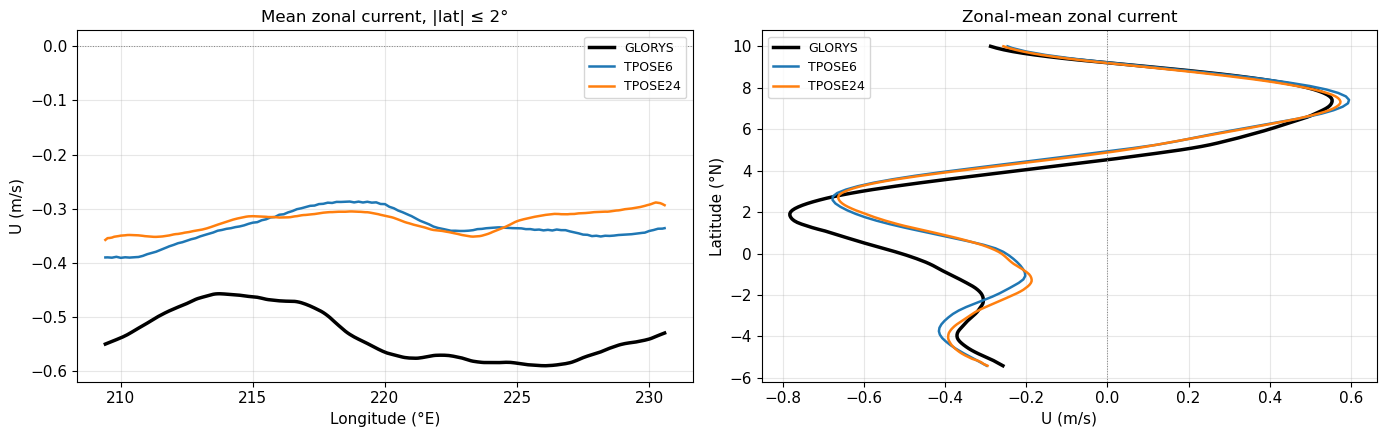

In [16]:
# ── Surface currents: equatorial zonal current + meridional profile ─
band = np.abs(LAT) <= BAND_HALF
w = np.cos(np.deg2rad(LAT[band]))[:, None]
def bm(a2d):
    a = a2d[band, :]
    return np.nansum(a * w, axis=0) / np.nansum(w * np.isfinite(a), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(LON, bm(np.nanmean(OBS['u'], 0)), color='k', lw=2.5, label='GLORYS')
axes[1].plot(np.nanmean(np.nanmean(OBS['u'], 0), axis=1), LAT, color='k', lw=2.5, label='GLORYS')
for label in LABELS:
    um = np.nanmean(surf[label]['u'], 0)
    axes[0].plot(LON, bm(um), color=COLORS[label], lw=1.8, label=label)
    axes[1].plot(np.nanmean(um, axis=1), LAT, color=COLORS[label], lw=1.8, label=label)
axes[0].axhline(0, color='gray', lw=0.7, ls=':')
axes[0].set_title(f'Mean zonal current, |lat| ≤ {BAND_HALF:g}°')
axes[0].set_xlabel('Longitude (°E)'); axes[0].set_ylabel('U (m/s)')
axes[1].axvline(0, color='gray', lw=0.7, ls=':')
axes[1].set_title('Zonal-mean zonal current')
axes[1].set_xlabel('U (m/s)'); axes[1].set_ylabel('Latitude (°N)')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/currents_1d_zonal_meridional.png', dpi=150, bbox_inches='tight')
plt.show()

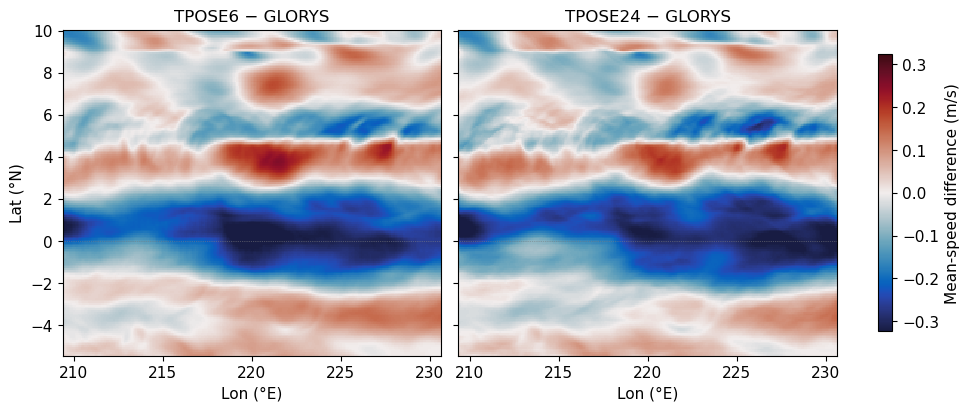

In [17]:
# ── Surface currents: mean-speed difference maps (model − GLORYS) ───
sdiff = {label: spd[label] - spd['GLORYS'] for label in LABELS}
dmax = np.nanmax([np.nanpercentile(np.abs(d), 99) for d in sdiff.values()])
n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True, squeeze=False)
axes = axes[0]
for ax, label in zip(axes, LABELS):
    im = add_map(ax, LON, LAT, sdiff[label], cmo.balance, -dmax, dmax)
    ax.set_title(f'{label} − GLORYS')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Mean-speed difference (m/s)', shrink=0.85)
fig.savefig(f'{OUTDIR}/currents_2d_speed_diff.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Build daily-sampled 3-D T/S on the comparison domain ────────────
# GLORYS T/S over the domain, top DEPTH_MAX m.
To = u.subset_domain(glor.thetao, *DOM).sel(depth=slice(0, DEPTH_MAX)).compute()
So = u.subset_domain(glor.so,     *DOM).sel(depth=slice(0, DEPTH_MAX)).compute()
GDEP = To.depth.values

def model_3d(sds, var, cfg):
    ztop = sds.Z.where(sds.Z >= -DEPTH_MAX, drop=True)
    da = sds[var].sel(Z=ztop)
    da = da.sel(XC=slice(DOM[0], DOM[1]), YC=slice(DOM[2], DOM[3]))
    da = da.where(da != 0)
    da = da.isel(time=slice(0, None, cfg['daily_step'])).sel(time=slice(T0, T1))
    return da.assign_coords(depth=('Z', -da.Z.values)).swap_dims({'Z': 'depth'})

theta_m, salt_m = {}, {}
for label, cfg in MODELS:
    theta_m[label] = model_3d(state_ds[label], 'THETA', cfg).compute()
    salt_m[label]  = model_3d(state_ds[label], 'SALT',  cfg).compute()
    print(f'[{label}] 3-D sampled days: {theta_m[label].sizes["time"]}, '
          f'levels: {theta_m[label].sizes["depth"]}')

[TPOSE6] 3-D sampled days: 91, levels: 41


[TPOSE24] 3-D sampled days: 91, levels: 82


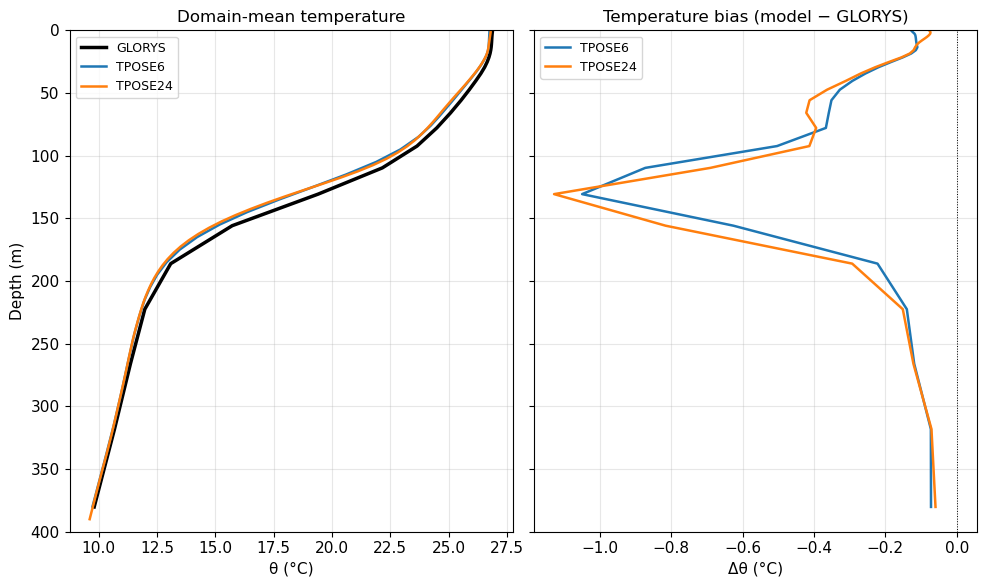

In [19]:
# ── Temperature: domain-mean profile + bias vs GLORYS ───────────────
prof_o = g.profile_domain_mean(To.mean('time'))
prof_m = {label: g.profile_domain_mean(theta_m[label].mean('time'), 'YC', 'XC')
          for label in LABELS}

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
axes[0].plot(prof_o.values, GDEP, color='k', lw=2.5, label='GLORYS')
for label in LABELS:
    d = prof_m[label].depth.values
    axes[0].plot(prof_m[label].values, d, color=COLORS[label], lw=1.8, label=label)
    interp = np.interp(GDEP, prof_m[label].depth.values, prof_m[label].values)
    axes[1].plot(interp - prof_o.values, GDEP, color=COLORS[label], lw=1.8, label=label)
axes[0].set_title('Domain-mean temperature'); axes[0].set_xlabel('θ (°C)')
axes[0].set_ylabel('Depth (m)')
axes[1].axvline(0, color='k', lw=0.7, ls=':')
axes[1].set_title('Temperature bias (model − GLORYS)'); axes[1].set_xlabel('Δθ (°C)')
for ax in axes:
    ax.set_ylim(DEPTH_MAX, 0); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/temp_1d_profile_bias.png', dpi=150, bbox_inches='tight')
plt.show()

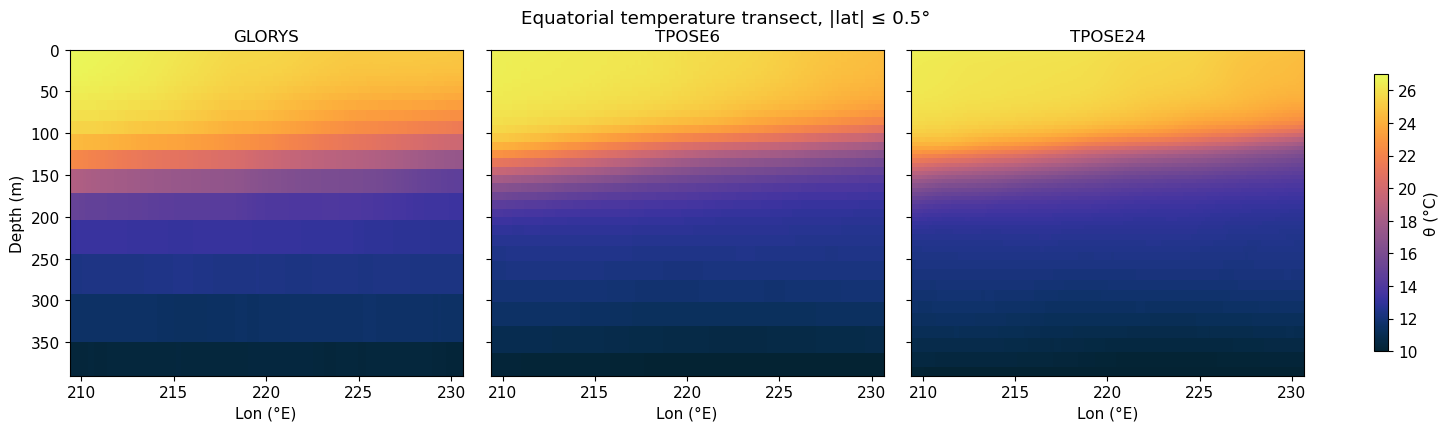

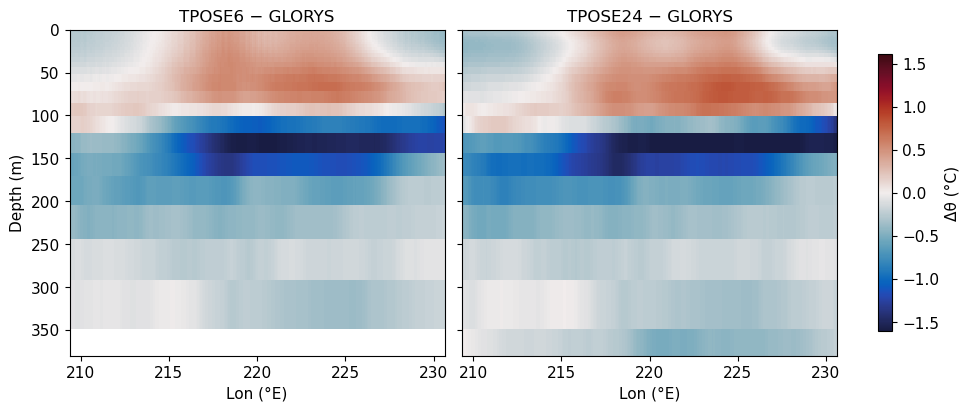

In [20]:
# ── Temperature: equatorial depth–longitude transect + difference ───
teq = {'GLORYS': g.band_mean(To, 'latitude', EQ_HALF).mean('time')}
for label in LABELS:
    teq[label] = g.band_mean(theta_m[label], 'YC', EQ_HALF).mean('time')

vmin = np.floor(np.nanmin(teq['GLORYS'].values))
vmax = np.ceil(np.nanmax(teq['GLORYS'].values))
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    x = teq[p].longitude.values if p == 'GLORYS' else teq[p].XC.values
    dz = teq[p].depth.values
    im = add_transect(ax, x, dz, teq[p].values, cmo.thermal, vmin, vmax, 'Lon (°E)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='θ (°C)', shrink=0.85)
fig.suptitle(f'Equatorial temperature transect, |lat| ≤ {EQ_HALF:g}°', y=1.04)
fig.savefig(f'{OUTDIR}/temp_2d_eq_transect.png', dpi=150, bbox_inches='tight')
plt.show()

# differences (model interpolated onto GLORYS lon/depth)
dmax_t = 0
tdiff = {}
for label in LABELS:
    mi = teq[label].interp(XC=To.longitude.values, depth=GDEP)
    tdiff[label] = mi.values - teq['GLORYS'].values
    dmax_t = max(dmax_t, np.nanpercentile(np.abs(tdiff[label]), 99))
n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True, squeeze=False)
axes = axes[0]
for ax, label in zip(axes, LABELS):
    im = add_transect(ax, To.longitude.values, GDEP, tdiff[label], cmo.balance,
                      -dmax_t, dmax_t, 'Lon (°E)')
    ax.set_title(f'{label} − GLORYS')
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='Δθ (°C)', shrink=0.85)
fig.savefig(f'{OUTDIR}/temp_2d_eq_transect_diff.png', dpi=150, bbox_inches='tight')
plt.show()

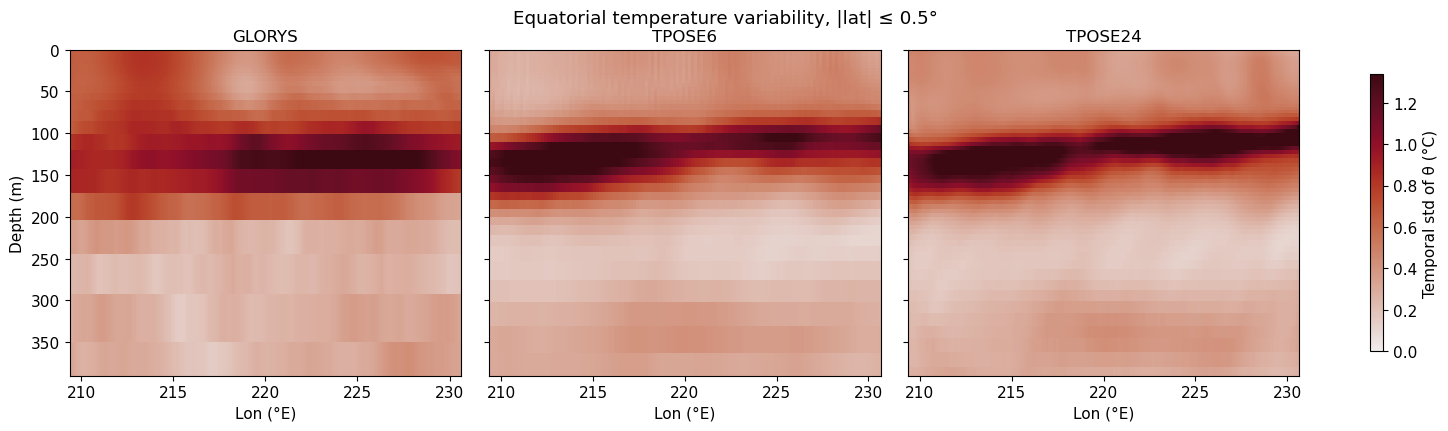

In [21]:
# ── Temperature: equatorial temporal-std transect ───────────────────
tstd = {'GLORYS': g.band_mean(To, 'latitude', EQ_HALF).std('time')}
for label in LABELS:
    tstd[label] = g.band_mean(theta_m[label], 'YC', EQ_HALF).std('time')
vmax = np.nanpercentile(tstd['GLORYS'].values, 99)
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    x = tstd[p].longitude.values if p == 'GLORYS' else tstd[p].XC.values
    im = add_transect(ax, x, tstd[p].depth.values, tstd[p].values, cmo.amp, 0, vmax, 'Lon (°E)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='Temporal std of θ (°C)', shrink=0.85)
fig.suptitle(f'Equatorial temperature variability, |lat| ≤ {EQ_HALF:g}°', y=1.04)
fig.savefig(f'{OUTDIR}/temp_2d_eq_variability.png', dpi=150, bbox_inches='tight')
plt.show()

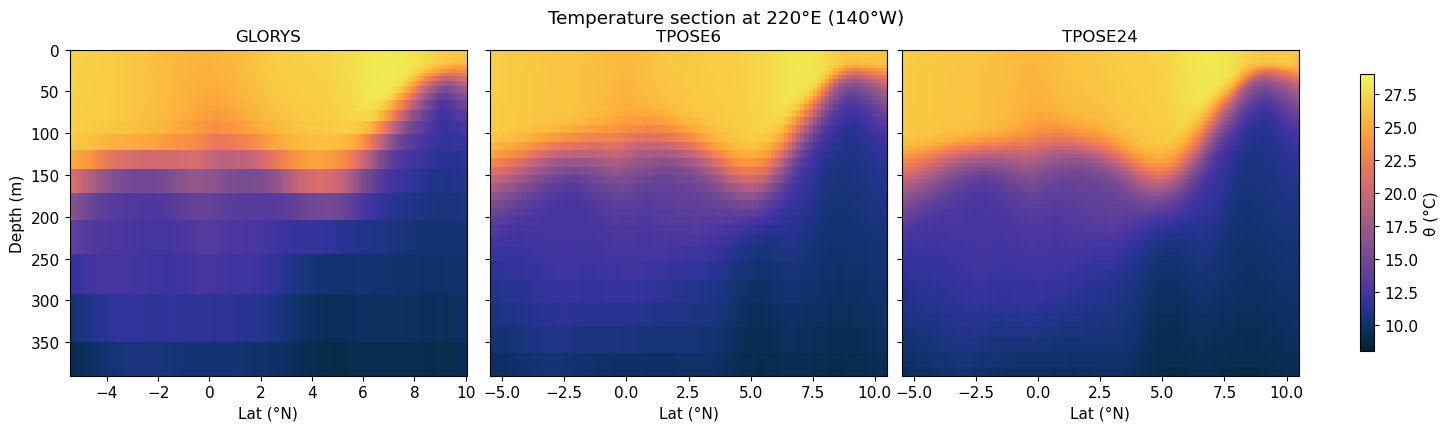

In [22]:
# ── Temperature: 140°W meridional depth–latitude section ────────────
tsec = {'GLORYS': To.sel(longitude=SECTION_LON, method='nearest').mean('time')}
for label in LABELS:
    tsec[label] = theta_m[label].sel(XC=SECTION_LON, method='nearest').mean('time')
vmin = np.floor(np.nanmin(tsec['GLORYS'].values)); vmax = np.ceil(np.nanmax(tsec['GLORYS'].values))
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    y = tsec[p].latitude.values if p == 'GLORYS' else tsec[p].YC.values
    im = add_transect(ax, y, tsec[p].depth.values, tsec[p].values, cmo.thermal, vmin, vmax, 'Lat (°N)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='θ (°C)', shrink=0.85)
fig.suptitle(f'Temperature section at {SECTION_LON:g}°E (140°W)', y=1.04)
fig.savefig(f'{OUTDIR}/temp_2d_meridional_section.png', dpi=150, bbox_inches='tight')
plt.show()

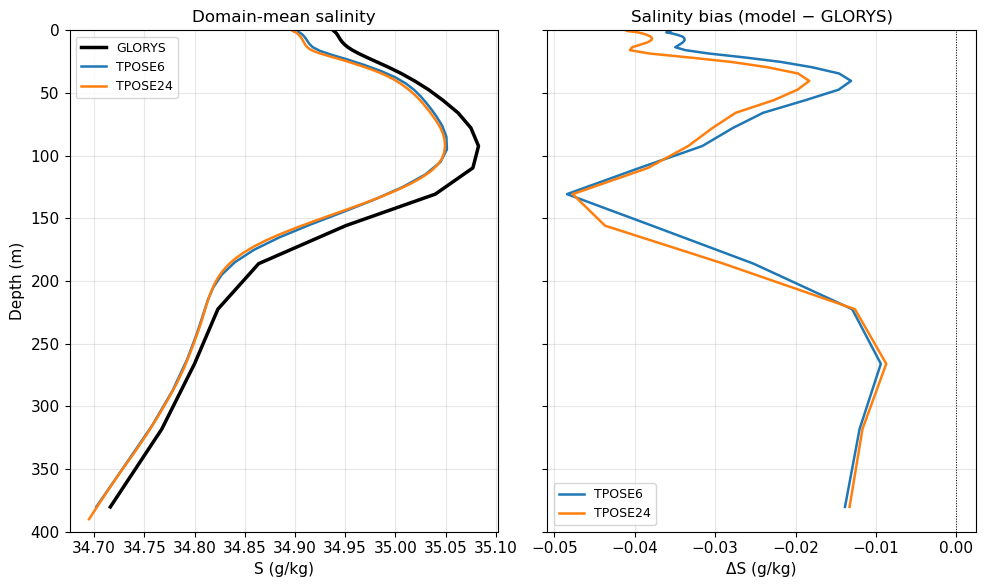

In [23]:
# ── Salinity: domain-mean profile + bias vs GLORYS ──────────────────
sprof_o = g.profile_domain_mean(So.mean('time'))
sprof_m = {label: g.profile_domain_mean(salt_m[label].mean('time'), 'YC', 'XC')
           for label in LABELS}

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
axes[0].plot(sprof_o.values, GDEP, color='k', lw=2.5, label='GLORYS')
for label in LABELS:
    d = sprof_m[label].depth.values
    axes[0].plot(sprof_m[label].values, d, color=COLORS[label], lw=1.8, label=label)
    interp = np.interp(GDEP, sprof_m[label].depth.values, sprof_m[label].values)
    axes[1].plot(interp - sprof_o.values, GDEP, color=COLORS[label], lw=1.8, label=label)
axes[0].set_title('Domain-mean salinity'); axes[0].set_xlabel('S (g/kg)')
axes[0].set_ylabel('Depth (m)')
axes[1].axvline(0, color='k', lw=0.7, ls=':')
axes[1].set_title('Salinity bias (model − GLORYS)'); axes[1].set_xlabel('ΔS (g/kg)')
for ax in axes:
    ax.set_ylim(DEPTH_MAX, 0); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/salt_1d_profile_bias.png', dpi=150, bbox_inches='tight')
plt.show()

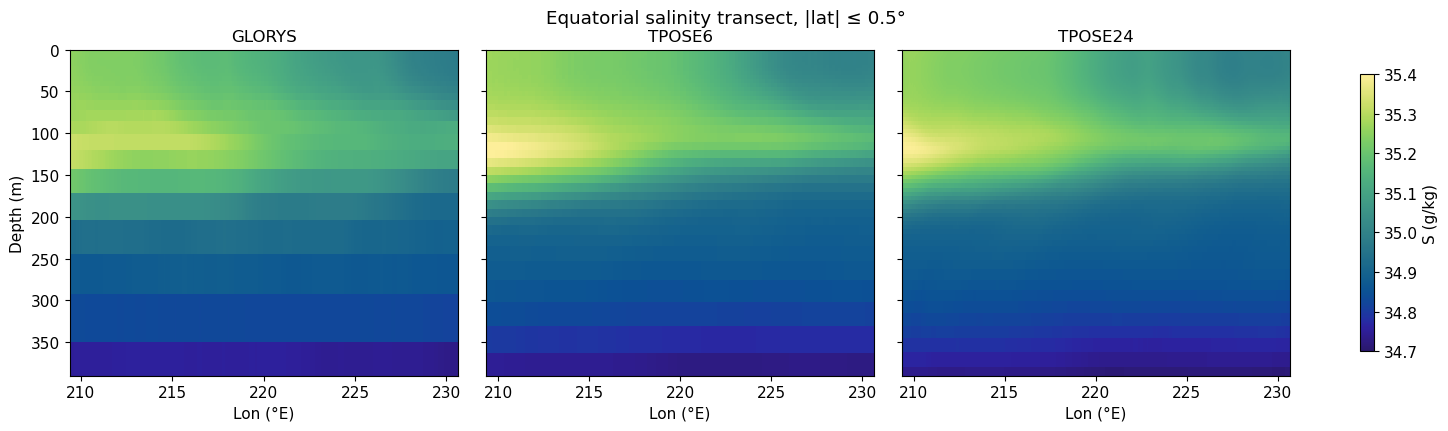

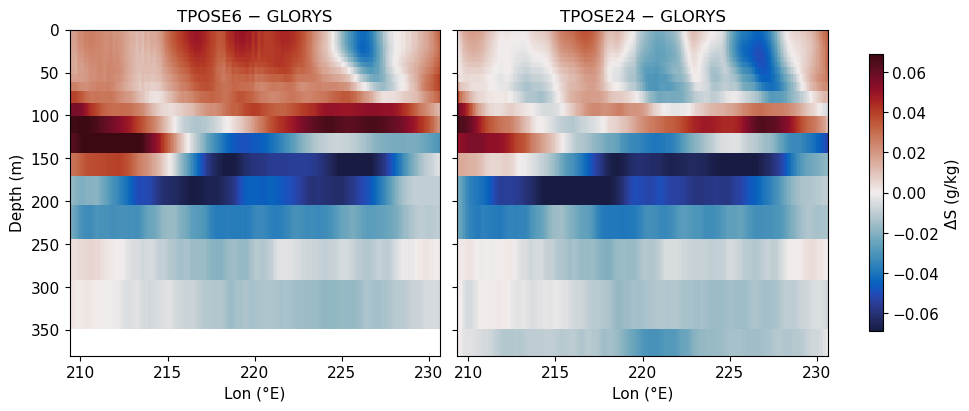

In [24]:
# ── Salinity: equatorial depth–longitude transect + difference ──────
seq = {'GLORYS': g.band_mean(So, 'latitude', EQ_HALF).mean('time')}
for label in LABELS:
    seq[label] = g.band_mean(salt_m[label], 'YC', EQ_HALF).mean('time')
vmin = np.floor(np.nanmin(seq['GLORYS'].values) * 10) / 10
vmax = np.ceil(np.nanmax(seq['GLORYS'].values) * 10) / 10
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    x = seq[p].longitude.values if p == 'GLORYS' else seq[p].XC.values
    im = add_transect(ax, x, seq[p].depth.values, seq[p].values, cmo.haline, vmin, vmax, 'Lon (°E)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='S (g/kg)', shrink=0.85)
fig.suptitle(f'Equatorial salinity transect, |lat| ≤ {EQ_HALF:g}°', y=1.04)
fig.savefig(f'{OUTDIR}/salt_2d_eq_transect.png', dpi=150, bbox_inches='tight')
plt.show()

dmax_s = 0
sdiff = {}
for label in LABELS:
    mi = seq[label].interp(XC=So.longitude.values, depth=GDEP)
    sdiff[label] = mi.values - seq['GLORYS'].values
    dmax_s = max(dmax_s, np.nanpercentile(np.abs(sdiff[label]), 99))
n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True, squeeze=False)
axes = axes[0]
for ax, label in zip(axes, LABELS):
    im = add_transect(ax, So.longitude.values, GDEP, sdiff[label], cmo.balance,
                      -dmax_s, dmax_s, 'Lon (°E)')
    ax.set_title(f'{label} − GLORYS')
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='ΔS (g/kg)', shrink=0.85)
fig.savefig(f'{OUTDIR}/salt_2d_eq_transect_diff.png', dpi=150, bbox_inches='tight')
plt.show()

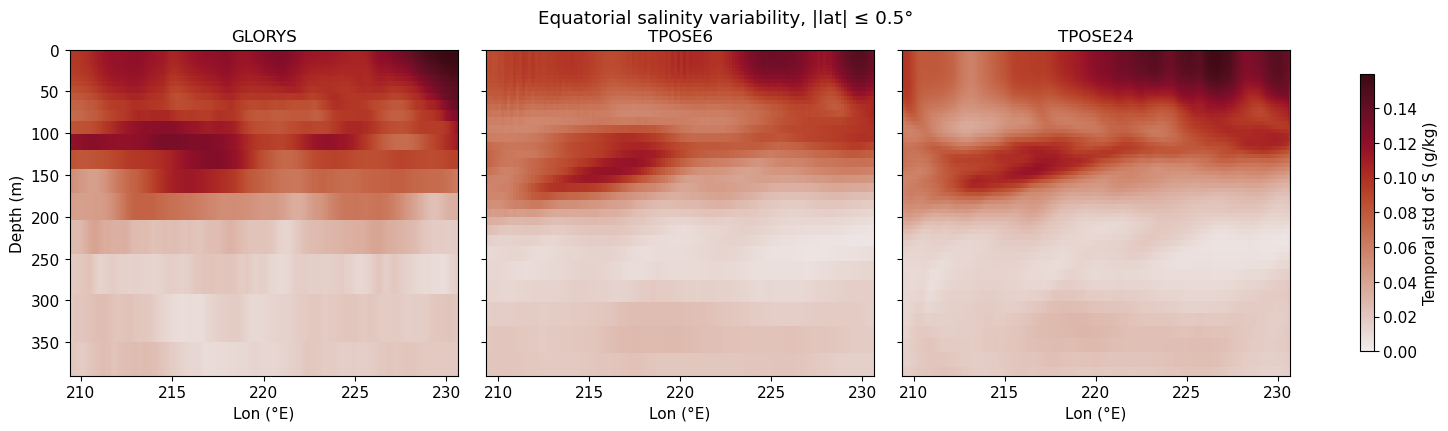

In [25]:
# ── Salinity: equatorial temporal-std transect ──────────────────────
sstd = {'GLORYS': g.band_mean(So, 'latitude', EQ_HALF).std('time')}
for label in LABELS:
    sstd[label] = g.band_mean(salt_m[label], 'YC', EQ_HALF).std('time')
vmax = np.nanpercentile(sstd['GLORYS'].values, 99)
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    x = sstd[p].longitude.values if p == 'GLORYS' else sstd[p].XC.values
    im = add_transect(ax, x, sstd[p].depth.values, sstd[p].values, cmo.amp, 0, vmax, 'Lon (°E)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='Temporal std of S (g/kg)', shrink=0.85)
fig.suptitle(f'Equatorial salinity variability, |lat| ≤ {EQ_HALF:g}°', y=1.04)
fig.savefig(f'{OUTDIR}/salt_2d_eq_variability.png', dpi=150, bbox_inches='tight')
plt.show()

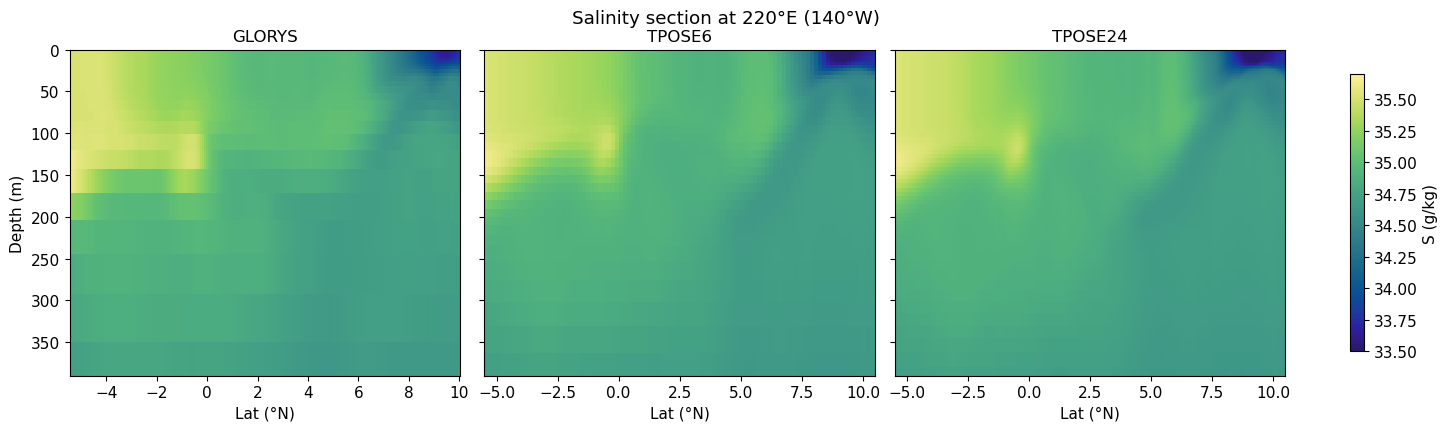

In [26]:
# ── Salinity: 140°W meridional depth–latitude section ───────────────
ssec = {'GLORYS': So.sel(longitude=SECTION_LON, method='nearest').mean('time')}
for label in LABELS:
    ssec[label] = salt_m[label].sel(XC=SECTION_LON, method='nearest').mean('time')
vmin = np.floor(np.nanmin(ssec['GLORYS'].values) * 10) / 10
vmax = np.ceil(np.nanmax(ssec['GLORYS'].values) * 10) / 10
n = len(PRODUCTS)
fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, PRODUCTS):
    y = ssec[p].latitude.values if p == 'GLORYS' else ssec[p].YC.values
    im = add_transect(ax, y, ssec[p].depth.values, ssec[p].values, cmo.haline, vmin, vmax, 'Lat (°N)')
    ax.set_title(p)
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, label='S (g/kg)', shrink=0.85)
fig.suptitle(f'Salinity section at {SECTION_LON:g}°E (140°W)', y=1.04)
fig.savefig(f'{OUTDIR}/salt_2d_meridional_section.png', dpi=150, bbox_inches='tight')
plt.show()